In [172]:
import importlib
from scipy.signal import savgol_filter
import os
import PKA_Sleep as PKA
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import r2_score
import json
from PKA_Sleep import Graphing_Utils as graph
from scipy.optimize import curve_fit
import glob
import pandas as pd
from scipy import stats
from sklearn.metrics import r2_score
from copy import deepcopy
graph.make_bigandbold()

In [187]:
def exponential_model(x, a, b, c):
    return a * np.exp(-b * x) + c
def linear_model(x, m, c):
    return m * x + c

In [16]:
# Get scopolamine
experiment_names = [[
                    'ltFLiPAKARmemEEGEMG0096-5',
                    'ltFLiPAKARmemEEGEMG0104-2',
                    'ltFLiPAKARmemEEGEMG0105-2',
                    'ltFLiPAKARmemEEGEMG0106-2',
                    'ltFLiPAKARmemEEGEMG0107-2',
                    'ltFLiPAKARmemEEGEMG0108'],
                    [
                    'ltFLiPAKARmemEEGEMG0094',
                    'ltFLiPAKARmemEEGEMG0099-1',
                    'ltFLiPAKARmemEEGEMG0099-2',
                    'ltFLiPAKARmemEEGEMG0100-1',
                    'ltFLiPAKARmemEEGEMG0101-1',
                    'ltFLiPAKARmemEEGEMG0102-1',
                    'ltFLiPAKARmemEEGEMG0103-1']]
mouse_names = [['4775',
                '5075',
                '5078',
                '5047',
                '5076',
                '5046'],
                ['4775', 
                 '5075', 
                 '5075', 
                 '5078', 
                 '5046', 
                 '5047', 
                 '5076']]

In [15]:
inj_info_fn = '/Volumes/yaochen/Active/Lizzie/FLP_data/injection_info.json'
with open(inj_info_fn, 'rb') as file:
    injection_info = json.load(file)

In [24]:
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 200
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False
emp_lifetime = False
gather_timestamps = True
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'

raw_datadirs = [[os.path.join(parent_data_directory, e) for e in exp_names] for exp_names in experiment_names]
excluded_acqs =[PKA.choose_excluded_acqs(r, first_acqs = 0, specific_acqs = False, pull_baseline = False) for r in raw_datadirs]
   
FLP_classes_dicts = [PKA.build_classes(e_names, m_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = emp_lifetime,
                                     parent_data_directory = parent_data_directory, gather_timestamps = gather_timestamps, 
                                      exclude_acqs = ex_acqs) for e_names, m_names, ex_acqs in 
                                 zip(experiment_names, mouse_names,excluded_acqs)]


You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint

No Saline period. Moving on...
No Saline period. Moving on...
No Saline period. Moving on...
No Saline period. Moving on...
No Saline period. Moving on...


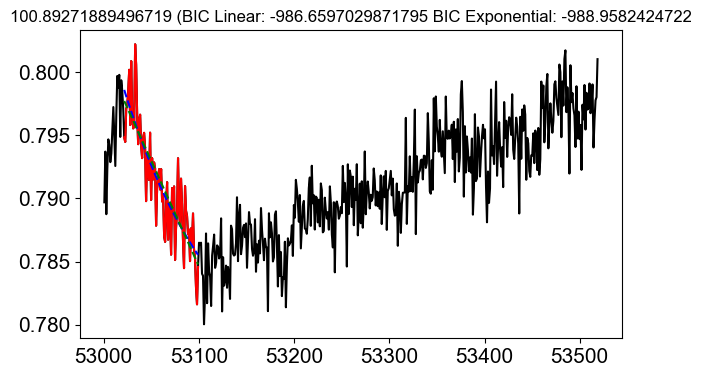

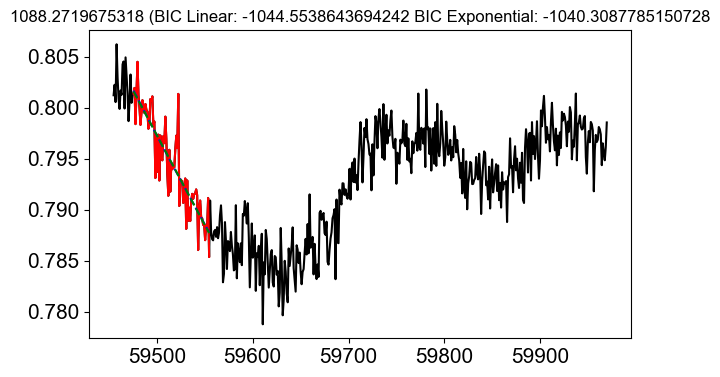

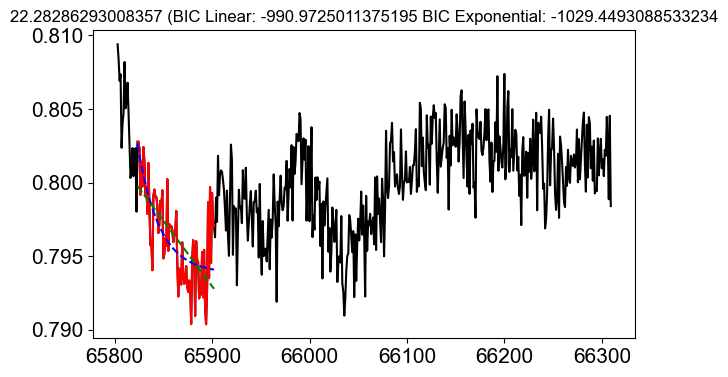

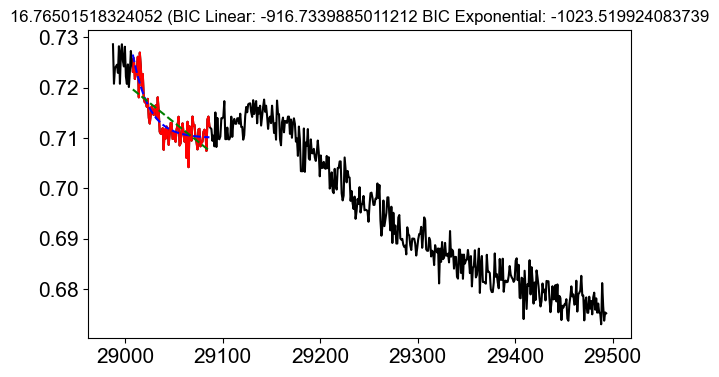

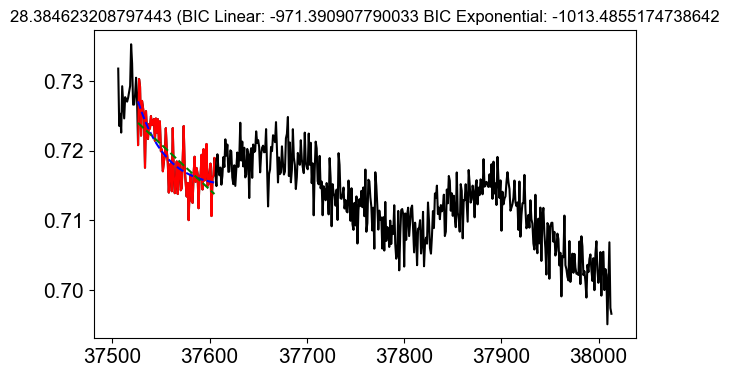

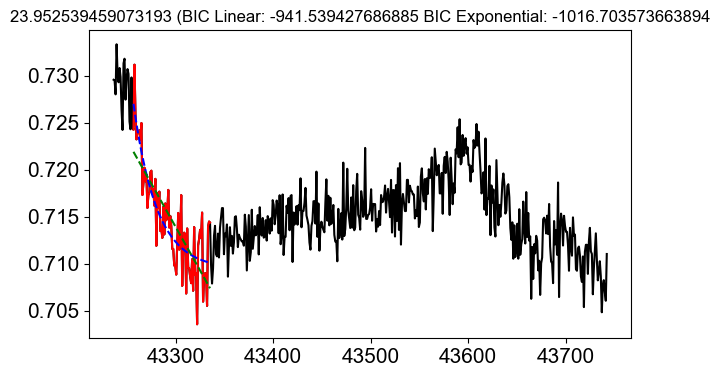

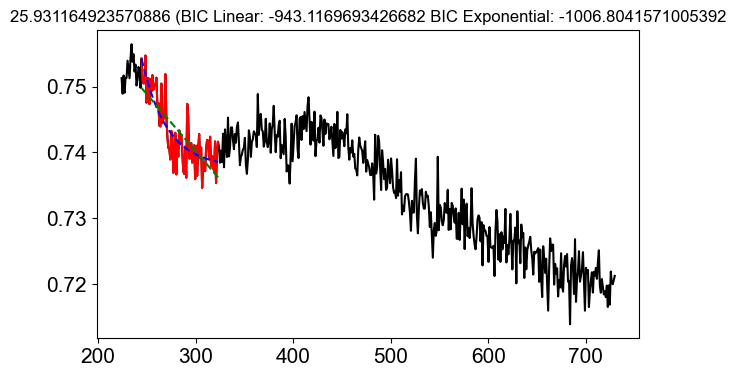

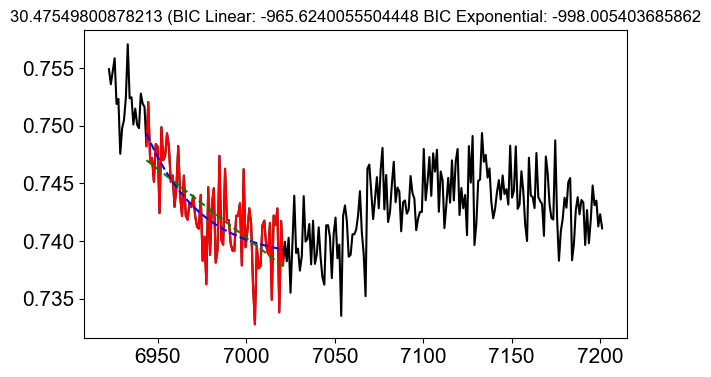

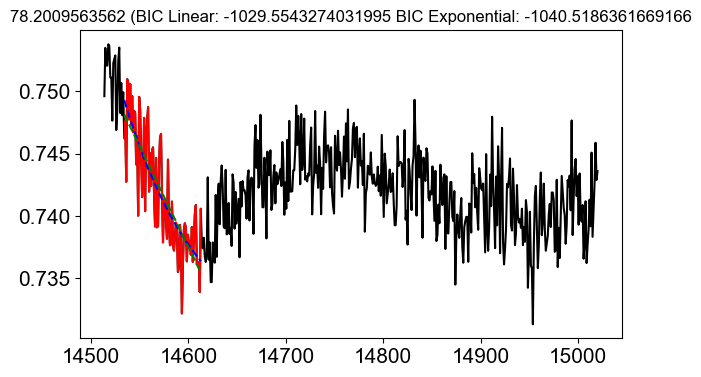

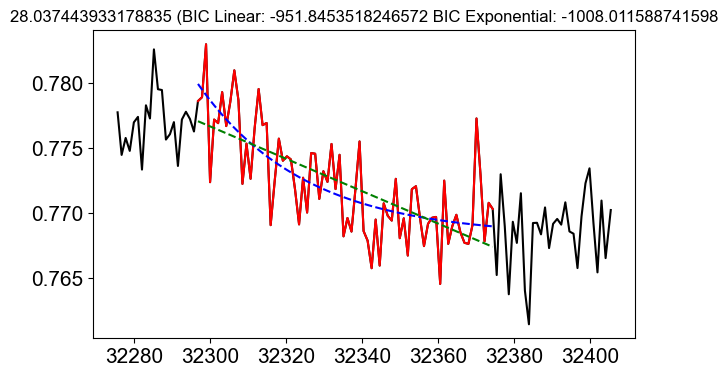

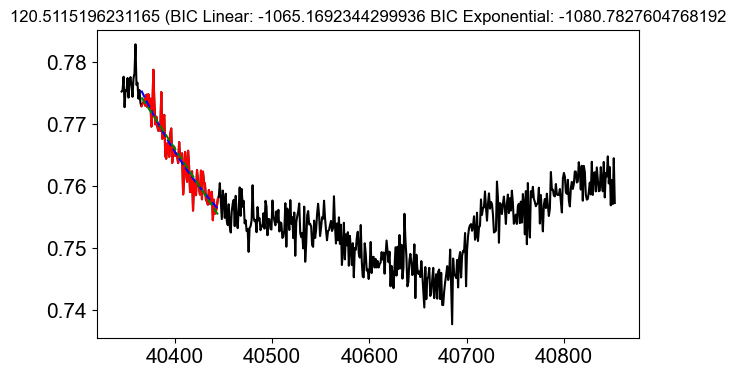

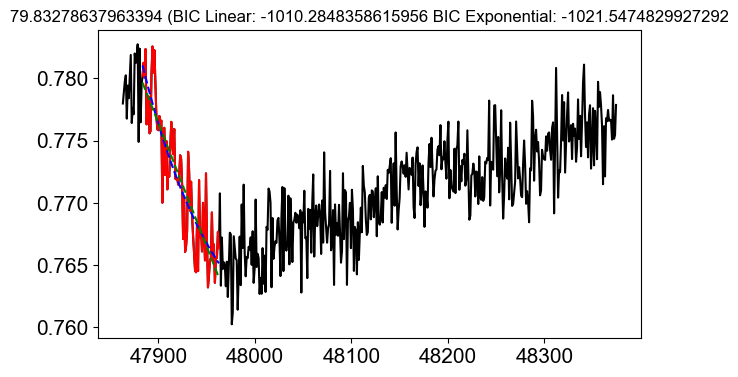

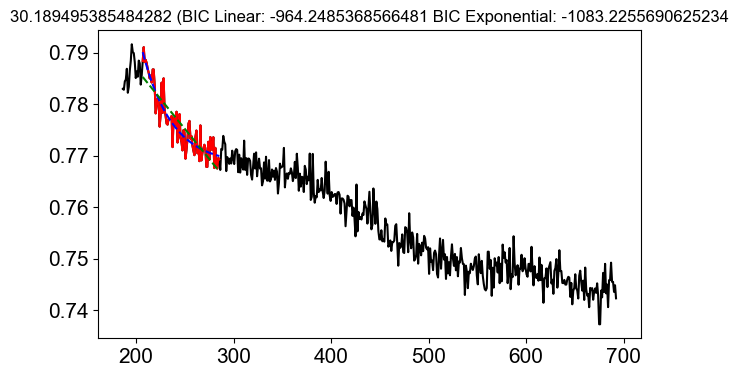

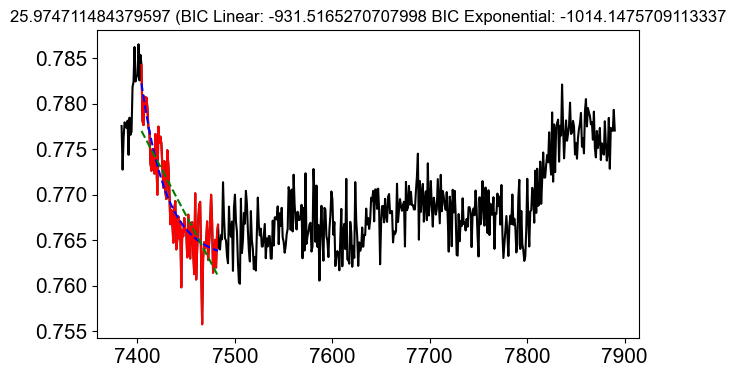

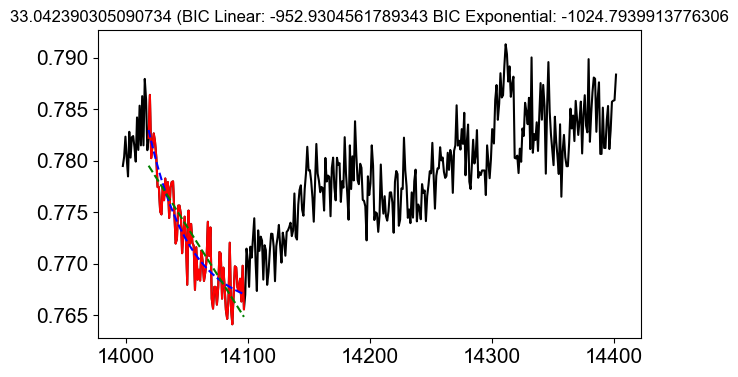

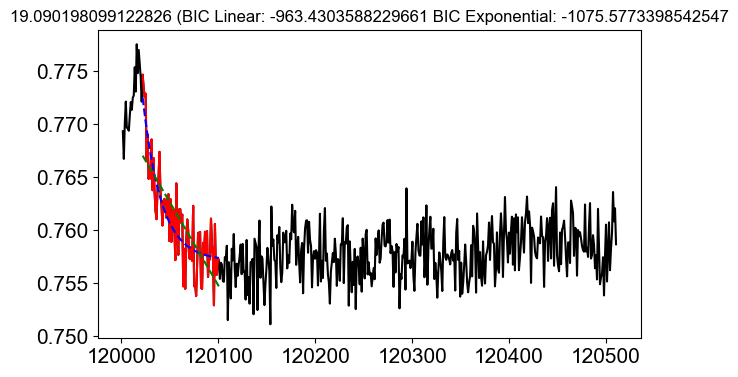

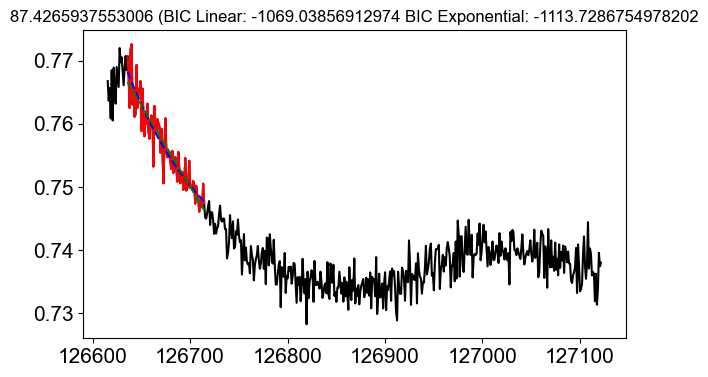

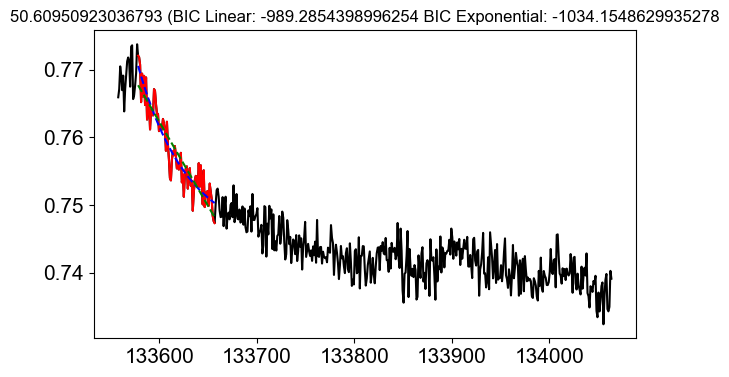

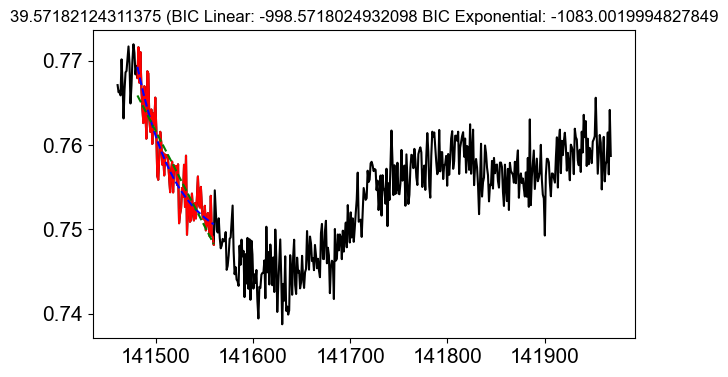

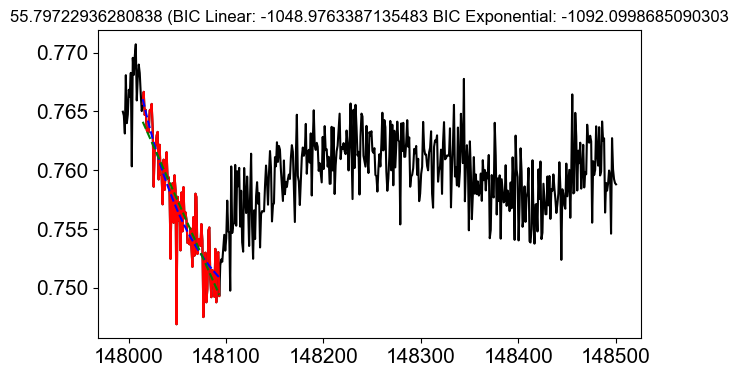

In [222]:
data_dict = {'Injection':{'pars':[], 'traces':[], 'animal':[], 'BIC Exponential':[], 'BIC Linear':[]}}
for b, FLP_exp,m in zip(FLP_classes_dicts[0]['Experiment Names'], FLP_classes_dicts[0]['Experiment Classes'], 
                        FLP_classes_dicts[0]['Animal Names']):
    FLP_exp.add_drug_epochs(injection_info, '%Y-%m-%dT%H:%M:%S.%f', [b], 'injection', post_injection_buffer = 100)
    for a in np.unique(FLP_exp.AcqNum):
        acq_idx, = np.where(FLP_exp.AcqNum == a)
        if any(FLP_exp.EpochID[acq_idx] == 2):
            inj_idx, = np.where(FLP_exp.EpochID[acq_idx] == 2)
            end_idx = inj_idx[-1]+400
            t = FLP_exp.Time[acq_idx][inj_idx[20:]]
            LFT = FLP_exp.Lifetime[acq_idx][inj_idx[20:]]
            if end_idx > len(acq_idx):
                end_idx = len(acq_idx)
            filt_LFT = savgol_filter(LFT, 11, 2)
            try:
                popt_exp, pcov_exp = curve_fit(exponential_model, t-t[0], filt_LFT)
                popt_lin, pcov_lin = curve_fit(linear_model, t-t[0], filt_LFT)
            except RuntimeError:
                continue
            y_fit_exp = exponential_model(t-t[0], popt_exp[0], popt_exp[1], popt_exp[2])
            y_fit_lin = linear_model(t-t[0], popt_lin[0], popt_lin[1])

            for fit, label, pars in zip([y_fit_exp, y_fit_lin], ['Exponential', 'Linear'], [popt_exp, popt_lin]):
                residuals = filt_LFT - fit
                sse = np.sum(residuals**2)
                n = len(y_fit_exp)             # Number of data points
                k = len(pars)               # Number of parameters (a, b, c = 3)
                sigma2 = sse / n            # Maximum Likelihood Estimate of the variance
                bic = n * np.log(sse / n) + k * np.log(n)
                data_dict['Injection']['BIC ' + label].append(bic)

            data_dict['Injection']['pars'].append(popt_exp)
            data_dict['Injection']['traces'].append(FLP_exp.Lifetime[acq_idx][inj_idx[0]:end_idx])
            data_dict['Injection']['animal'].append(m)
            # try:
            #     popt, pcov = curve_fit(exponential_model, t-t[0], LFT)
            # except RuntimeError:
            #     data_dict['Injection']['pars'].append((np.nan, np.nan, np.nan))
            #     data_dict['Injection']['animal'].append(m)
            #     continue
            # a_fit, b_fit, c_fit = popt
            # y_fit = exponential_model(t-t[0], a_fit, b_fit, c_fit)
            fig, ax = plt.subplots(figsize = [7,4])
            ax.plot(FLP_exp.Time[acq_idx][inj_idx[0]:end_idx], FLP_exp.Lifetime[acq_idx][inj_idx[0]:end_idx], color = 'k')
            ax.plot(t, LFT, color = 'r')
            ax.plot(t, y_fit_exp, color = 'b', linestyle = '--')
            ax.plot(t, y_fit_lin, color = 'g', linestyle = '--')
            ax.set_title(str(1/popt_exp[1]) + ' ' + '(BIC Linear: ' + str(data_dict['Injection']['BIC Linear'][-1]) + ' BIC Exponential: '+str(data_dict['Injection']['BIC Exponential'][-1]))

            # # pars, opt, bounds, (grid, grid_losses) = twomodel.fit_animal(savgol_filter(FLP_exp.Lifetime[acq_idx][inj_idx], 11, 2), 
            # #                                                      n_global=2048, top_k=32, loss_kind="huber")
            # data_dict['Injection']['pars'].append(popt)
            # data_dict['Injection']['traces'].append(FLP_exp.Lifetime[acq_idx][inj_idx[0]:end_idx])
            # data_dict['Injection']['animal'].append(m)
            # # fitS, fitState, fitError, BIC_ar = PKA.two_model_fit(FLP_exp.Lifetime[acq_idx][inj_idx[0]:inj_idx[-1]+40], 40, 
            #                                          1-1/pars['B1'], pars['S1'], 1-1/pars['B2'], pars['S2'], plotflag=0)
            # ax.plot(FLP_exp.Time[acq_idx][inj_idx[0]:inj_idx[-1]+40][fitS != 0], fitS[fitS != 0], color = 'b', linestyle = '--')

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_14005/3420615289.py:2: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c


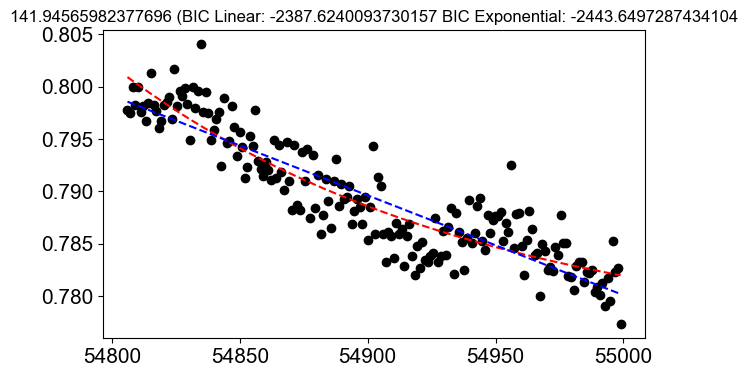

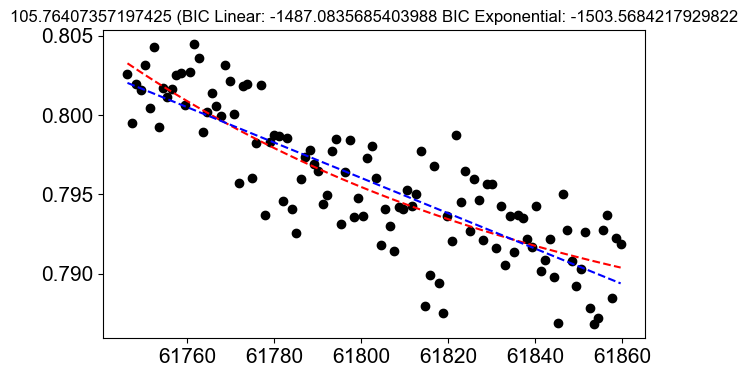

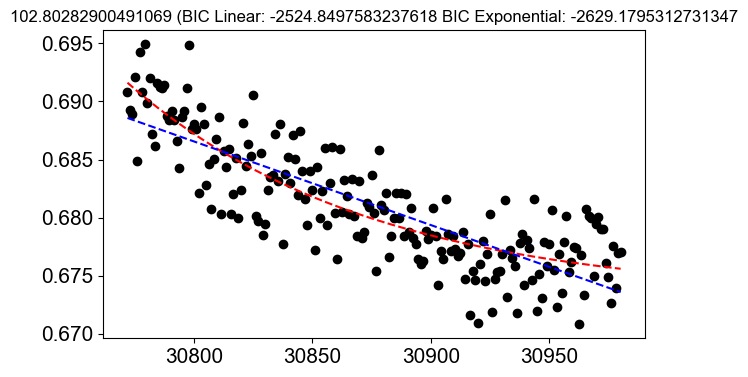

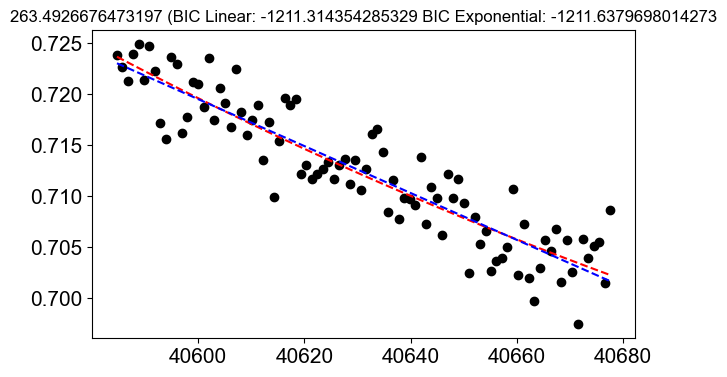

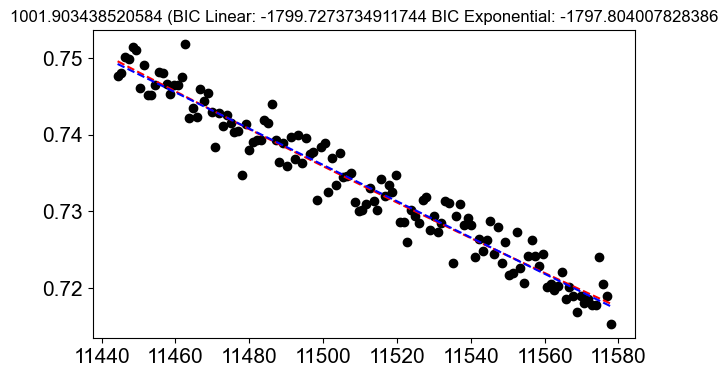

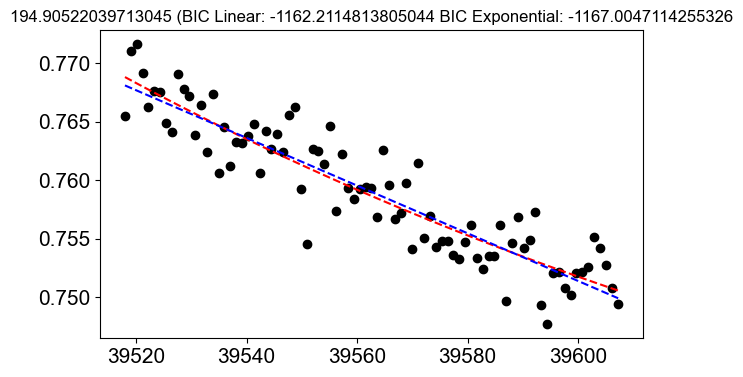

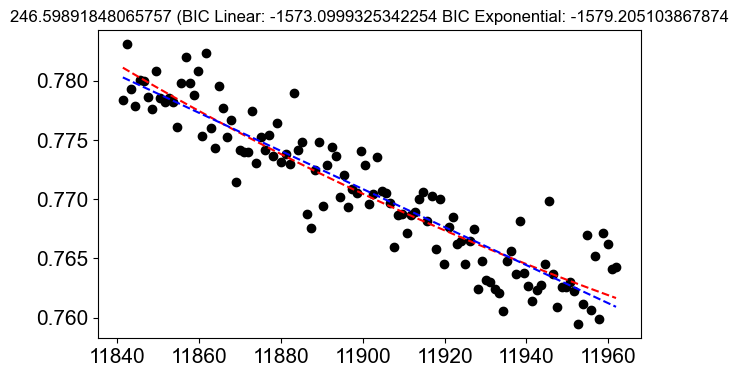

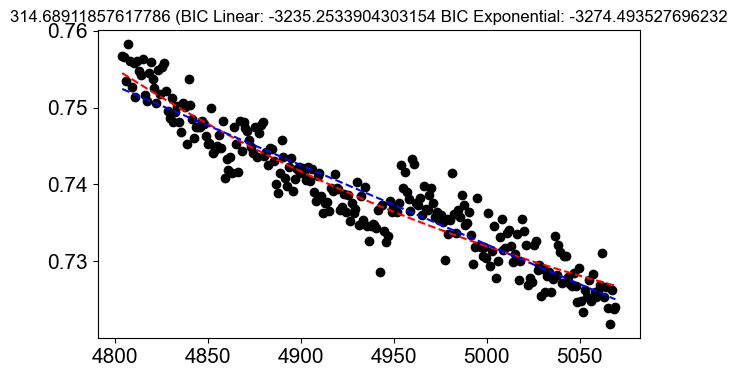

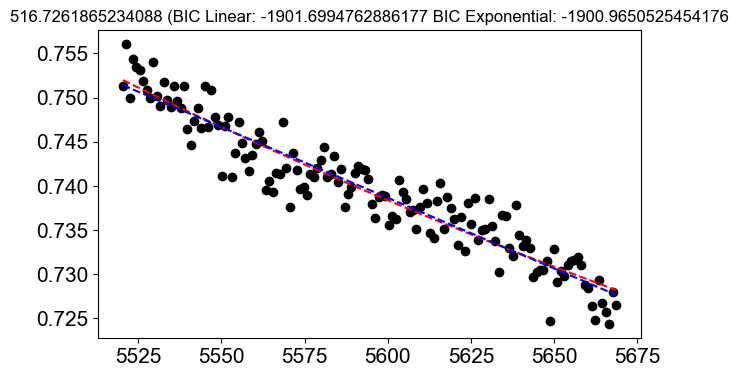

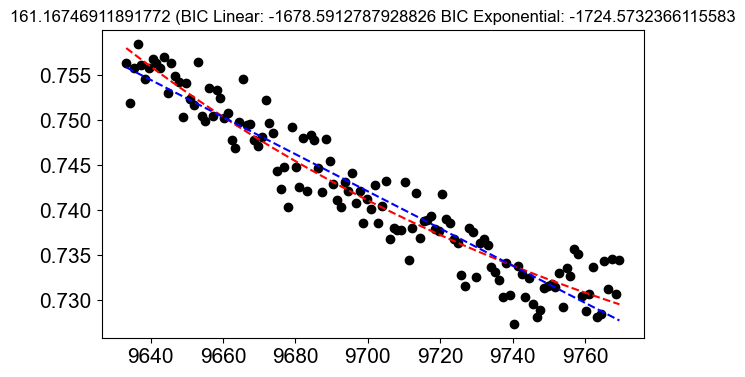

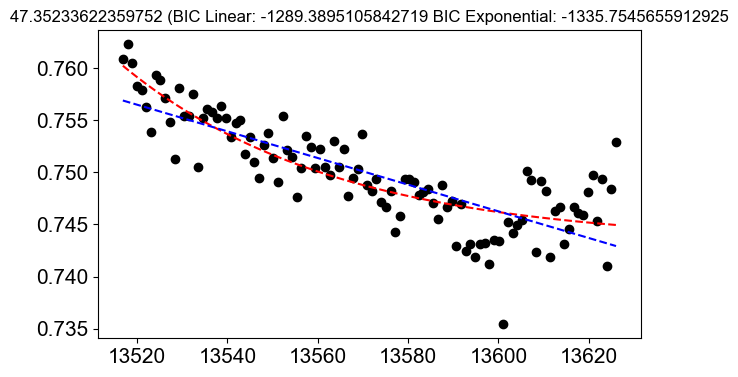

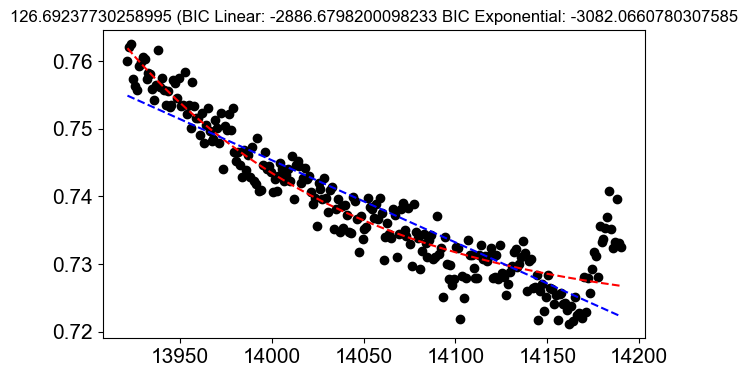

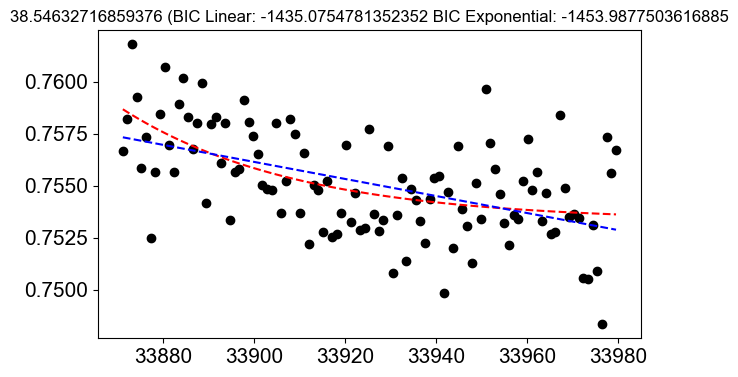

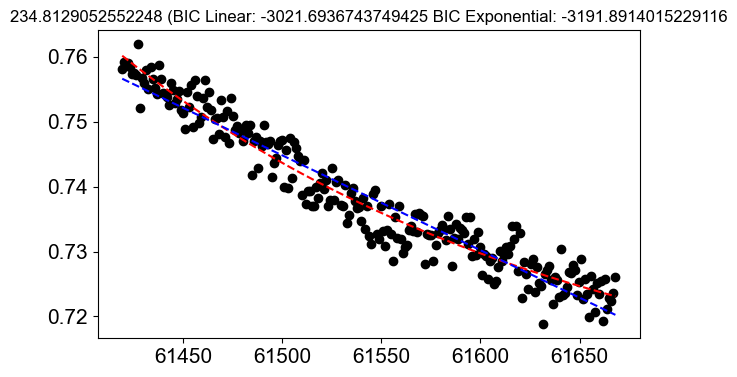

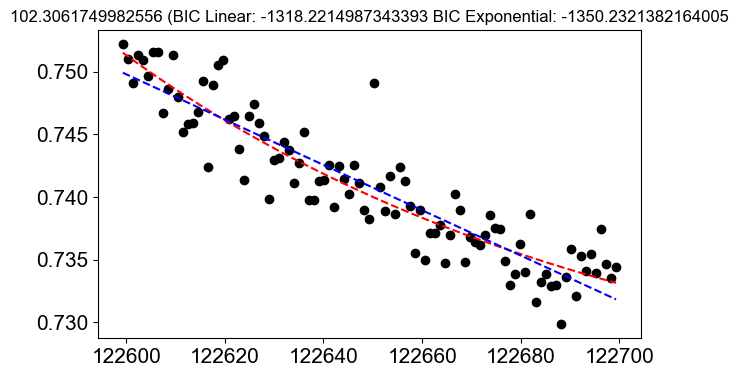

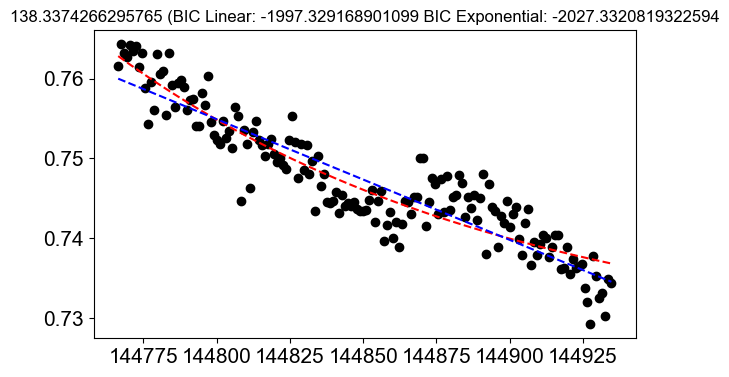

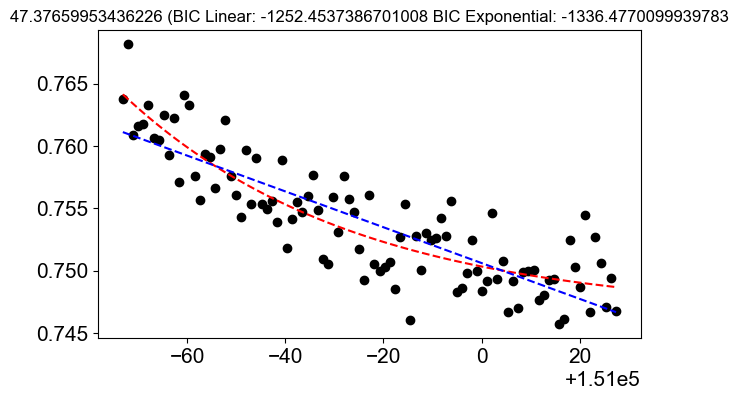

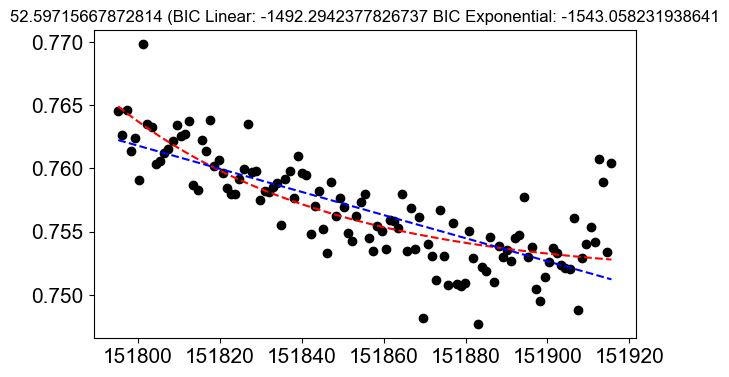

In [223]:
data_dict['Baseline'] = {'pars':[], 'traces':[], 'animal':[], 'r2':[], 'BIC Exponential':[], 'BIC Linear':[]}
for b, FLP_exp,m in zip(FLP_classes_dicts[0]['Experiment Names'], FLP_classes_dicts[0]['Experiment Classes'], 
                        FLP_classes_dicts[0]['Animal Names']):
    alt_ss = deepcopy(FLP_exp.SleepStates)
    alt_ss[alt_ss == 3] = 2
    onoff_df = FLP_exp.ss_onset_offset(alt_sleepstates=alt_ss)
    for b in onoff_df.loc[onoff_df['State'] == 2].index:
        this_bout = onoff_df.loc[b]
        prev_bout = onoff_df.loc[b-1]
        if (this_bout['Duration'] > 100) & (prev_bout['Duration'] > 75):
            t = FLP_exp.Time[(FLP_exp.Time >= this_bout['Start Time']) & (FLP_exp.Time < this_bout['End Time'])][10:]
            LFT = FLP_exp.Lifetime[(FLP_exp.Time >= this_bout['Start Time']) & (FLP_exp.Time < this_bout['End Time'])][10:]
            filt_LFT = savgol_filter(LFT, 11, 2)
            try:
                popt_exp, pcov_exp = curve_fit(exponential_model, t-t[0], filt_LFT)
                popt_lin, pcov_lin = curve_fit(linear_model, t-t[0], filt_LFT)
            except RuntimeError:
                continue
            y_fit_exp = exponential_model(t-t[0], popt_exp[0], popt_exp[1], popt_exp[2])
            y_fit_lin = linear_model(t-t[0], popt_lin[0], popt_lin[1])

            for fit, label, pars in zip([y_fit_exp, y_fit_lin], ['Exponential', 'Linear'], [popt_exp, popt_lin]):
                residuals = filt_LFT - fit
                sse = np.sum(residuals**2)
                n = len(y_fit_exp)             # Number of data points
                k = len(pars)               # Number of parameters (a, b, c = 3)
                sigma2 = sse / n            # Maximum Likelihood Estimate of the variance
                bic = n * np.log(sse / n) + k * np.log(n)
                data_dict['Baseline']['BIC ' + label].append(bic)

            data_dict['Baseline']['pars'].append(popt_exp)
            data_dict['Baseline']['traces'].append(LFT)
            data_dict['Baseline']['animal'].append(m)
            # data_dict['Baseline']['r2'].append(r2_score(filt_LFT, y_fit))
            

            fig, ax = plt.subplots(figsize = [7,4])
            ax.scatter(t, LFT, color = 'k')
            ax.plot(t, y_fit_exp, color = 'r', linestyle = '--')
            ax.plot(t, y_fit_lin, color = 'b', linestyle = '--')
            ax.set_title(str(1/popt_exp[1]) + ' ' + '(BIC Linear: ' + str(data_dict['Baseline']['BIC Linear'][-1]) + ' BIC Exponential: '+str(data_dict['Baseline']['BIC Exponential'][-1]))
            fig.savefig('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/twostate_model/NREM_Dephosphorylation_Fits/fit_'+str(b))

In [225]:
data_dict['Injection']['vstack_traces'] = np.empty([len(data_dict['Injection']['traces']),
                                                   max([len(l) for l in data_dict['Injection']['traces']])])
for i in range(len(data_dict['Injection']['traces'])):
    data_dict['Injection']['vstack_traces'][i] = np.nan
    data_dict['Injection']['vstack_traces'][i][:len(data_dict['Injection']['traces'][i])] = data_dict['Injection']['traces'][i]

data_dict['Baseline']['vstack_traces'] = np.empty([len(data_dict['Baseline']['traces']),
                                                   max([len(l) for l in data_dict['Baseline']['traces']])])
for i in range(len(data_dict['Baseline']['traces'])):
    data_dict['Baseline']['vstack_traces'][i] = np.nan
    data_dict['Baseline']['vstack_traces'][i,:len(data_dict['Baseline']['traces'][i])] = data_dict['Baseline']['traces'][i]

injection:0.019554747621618535
baseline:0.00972735876706498


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


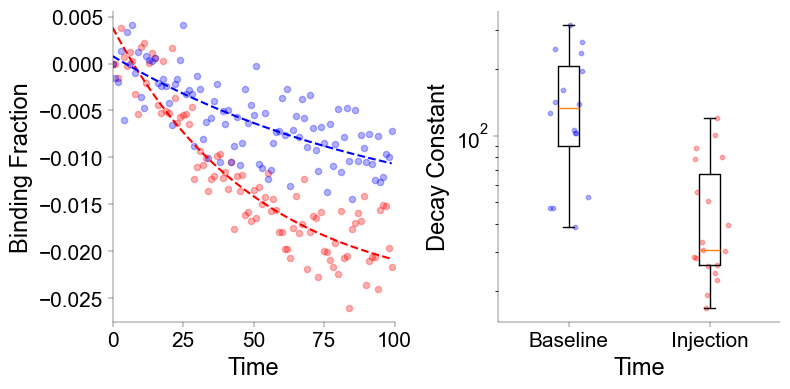

In [230]:
BIC_diff_baseline = np.array(data_dict['Baseline']['BIC Exponential'])-np.array(data_dict['Baseline']['BIC Linear'])
BIC_diff_drug = np.array(data_dict['Injection']['BIC Exponential'])-np.array(data_dict['Injection']['BIC Linear'])

baseline_idx = [i for i,b in enumerate(BIC_diff_baseline) if b < 0]
drugs_idx = [i for i,b in enumerate(BIC_diff_drug) if b < 0]
# drugs_idx = [i for i,b in enumerate(data_dict['Injection']['pars']) if (b[1] < 1) & (b[0] > 0)]
fig, ax = plt.subplots(figsize = [8, 4], ncols = 2)
colors = ['r', 'k']

# for i,k in enumerate(data_dict.keys()):
inj_ex = 5
x = np.arange(0,100)
y = data_dict['Injection']['vstack_traces'][inj_ex][0:100]
ax[0].scatter(x-x[0],y-y[0], s = 20, color = 'r', alpha = 0.3)
(a_fit, b_fit, c_fit),_ = popt, pcov = curve_fit(exponential_model, x-x[0], y)
print('injection:' + str(b_fit))
# a_fit, b_fit, c_fit = data_dict['Injection']['pars'][inj_ex]
y_fit = exponential_model(x, a_fit, b_fit, c_fit)
ax[0].plot(x, y_fit-y[0], color = 'r', linestyle = '--')

# baseline_ex = 2
baseline_ex = 2
x = np.arange(0,100)
y = data_dict['Baseline']['vstack_traces'][baseline_ex][0:100]
ax[0].scatter(x,y-y[0], s = 20, color = 'b', alpha = 0.3)
a_fit, b_fit, c_fit = data_dict['Baseline']['pars'][baseline_ex]
print('baseline:' + str(b_fit))
y_fit = exponential_model(x, a_fit, b_fit, c_fit)
ax[0].plot(x, y_fit-y[0], color = 'b', linestyle = '--')

ax[0].set_xlim([0, 100])


# graph.swarm_plot(fig, ax[1], [B2_baseline, B2_drugs], [0,1], ['k', 'r'], x_width=0.25, scatter_size=20)
# ax[1].boxplot([B2_baseline, B2_drugs], showfliers = False)
B2_baseline = [data_dict['Baseline']['pars'][i][1] for i in baseline_idx]
B2_drugs = [data_dict['Injection']['pars'][i][1] for i in drugs_idx]

ax[1].boxplot([1/np.array(B2_baseline),1/np.array(B2_drugs)], showfliers = False)
y1 = 1/np.array(B2_baseline)
x1 = graph.get_jittered_x(1, len(y1), width =0.15)
y2 = 1/np.array(B2_drugs)
x2 = graph.get_jittered_x(2, len(y2), width =0.15)
ax[1].scatter(x1, y1, color = 'b', alpha = 0.3, s = 10)
ax[1].scatter(x2, y2, color = 'r', alpha = 0.3, s = 10)
ax[1].set_yscale('log')
graph.thick_axes(fig, ax, width = 0.3)
graph.label_axes(ax[0], y = 'Binding Fraction', x = 'Time')
graph.label_axes(ax[1], y = 'Decay Constant', x = 'Time')

fig.tight_layout()
# ax.set_ylabel()
# ax.set_xticks([0,1])
ax[1].set_xticklabels(['Baseline', 'Injection'])
fig.savefig('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/twostate_model/slope_compare.ps')

In [233]:
from PKA_Sleep import FLPstats
import importlib; importlib.reload(FLPstats)

def group_by_animal(pars_list, animal_list):
    # Filter NaN pars first — the injection loop appends (nan,nan,nan) on
    # RuntimeError without appending to animal, so pars is longer than animal.
    # Removing NaN entries restores alignment before zipping.
    valid_pars = [p for p in pars_list if not any(np.isnan(p))]
    animal_data = {}
    for pars, animal in zip(valid_pars, animal_list):
        a, b, c = pars
        if np.isfinite(b) and np.isfinite(a):
            animal_data.setdefault(animal, []).append(np.log(b))
    return animal_data

baseline_grouped = group_by_animal(np.array(data_dict['Baseline']['pars'])[baseline_idx], 
                                   np.array(data_dict['Baseline']['animal'])[baseline_idx])
drug_grouped = group_by_animal(np.array(data_dict['Injection']['pars'])[drugs_idx], 
                               np.array(data_dict['Injection']['animal'])[drugs_idx])

shared_animals = sorted(set(baseline_grouped) & set(drug_grouped))

grouped_data = [
    [np.array(drug_grouped[m]) for m in shared_animals],
    [np.array(baseline_grouped[m]) for m in shared_animals],
]
grouped_mouseIDs = [shared_animals, shared_animals]
grouped_expnames = [[[m] for m in shared_animals], [[m] for m in shared_animals]]

stage1_df, perm_result, t_result = FLPstats.nested_analysis_stats_v2(
    grouped_data, grouped_expnames, grouped_mouseIDs,
    group_labels=['Drug', 'Baseline'],
    outcome_col='Data', subject_col='Mouse_ID', group_col='Group',
    paired=True
)

Stage 1: Computing robust subject-level means using HuberT...
  Processed 10 subject-group combinations
  Observations with downweighted data: 1

=== Stage 1: per-animal robust means ===
Mouse_ID    Group  robust_mean  robust_se  n_obs
    4775     Drug    -3.858938   0.755120      2
    4775 Baseline    -4.808328   0.147117      2
    5046     Drug    -3.874660   0.256888      5
    5046 Baseline    -4.602251   0.232641     10
    5047     Drug    -4.168407   0.434031      3
    5047 Baseline    -5.272513   0.000000      1
    5075     Drug    -3.113739   0.155165      3
    5075 Baseline    -5.103419   0.470606      2
    5076     Drug    -3.387470   0.070193      3
    5076 Baseline    -5.507763   0.000000      1

=== Stage 2 (PRIMARY): sign permutation, 32 arrangements ===
  Mean diff (Drug - Baseline): 1.3782
  p (two-tailed) = 0.0625  [minimum possible = 0.0625]

=== Stage 2 (SECONDARY): paired t-test ===
  t(4) = 4.862, p = 0.0083, Cohen's dz = 2.17
